In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('APY.csv')

In [3]:
df

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75
...,...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1241.0,1.45
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,2415.0,1.77
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2145.0,2.04
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2114.0,2.54


In [4]:
df.shape

(345336, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  object 
 1   District    345336 non-null  object 
 2   Crop        345327 non-null  object 
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  object 
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 21.1+ MB


In [6]:
df.isnull().sum()

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.duplicated().sum()

0

In [9]:
df.columns

Index(['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ',
       'Production', 'Yield'],
      dtype='object')

In [10]:
df['Crop_efficiency'] = df['Production']/df['Area ']

In [11]:
df['Production_level'] = np.where(
    df['Production'] > 5000, 'High',
    np.where(df['Production'] > 2000, 'Medium', 'Low')
)

In [12]:
df

,State,District,Crop,Crop_Year,Season,Area,Production,Yield,Crop_efficiency,Production_level
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40,1.399820,Medium
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40,1.400025,Medium
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74,0.737883,Medium
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64,0.641428,Medium
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75,0.751264,Medium
...,...,...,...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1241.0,1.45,1.451462,Low
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,2415.0,1.77,1.767936,Medium
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2145.0,2.04,2.038973,Medium
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2114.0,2.54,2.537815,Medium


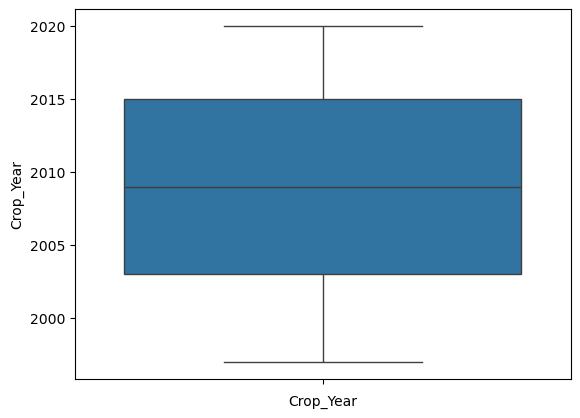

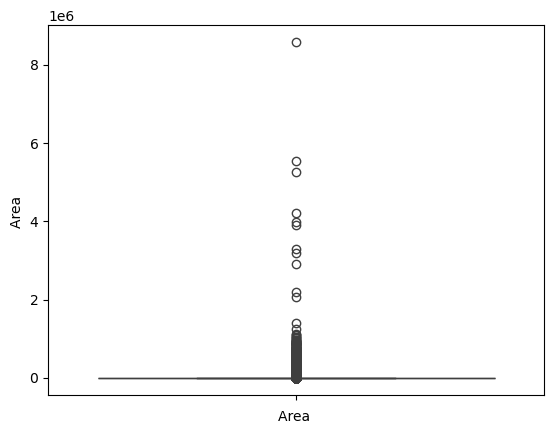

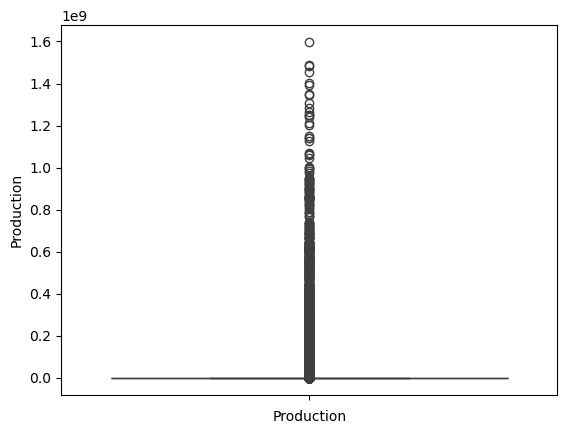

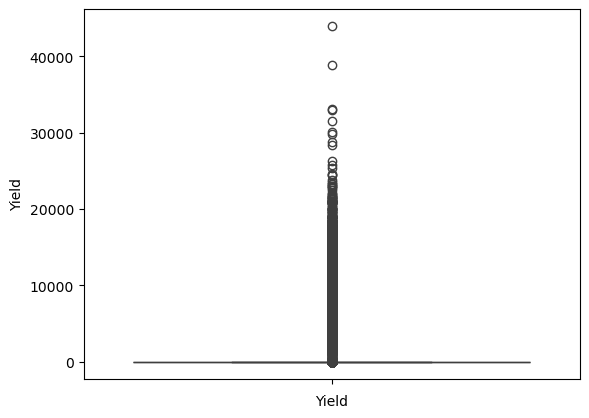

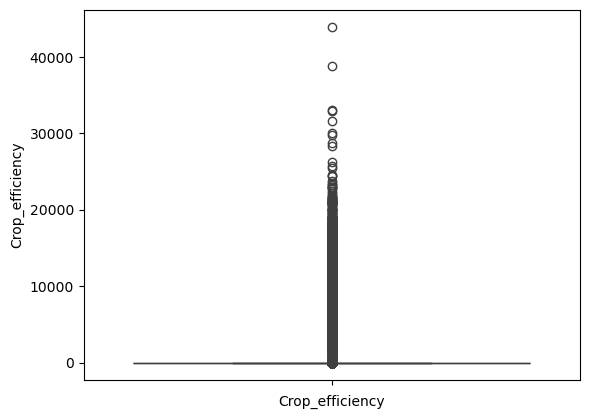

In [13]:
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [14]:
LE=LabelEncoder()

for col in df.columns:
  if df[col].dtype=='object':
    df[col]=LE.fit_transform(df[col])

In [15]:
df

,State,District,Crop,Crop_Year,Season,Area,Production,Yield,Crop_efficiency,Production_level
0,0,464,0,2007,1,2439.6,3415.0,1.40,1.399820,2
1,0,464,0,2007,2,1626.4,2277.0,1.40,1.400025,2
2,0,464,0,2008,0,4147.0,3060.0,0.74,0.737883,2
3,0,464,0,2008,3,4147.0,2660.0,0.64,0.641428,2
4,0,464,0,2009,0,4153.0,3120.0,0.75,0.751264,2
...,...,...,...,...,...,...,...,...,...,...
345331,36,516,53,2015,2,855.0,1241.0,1.45,1.451462,1
345332,36,516,53,2016,2,1366.0,2415.0,1.77,1.767936,2
345333,36,516,53,2017,2,1052.0,2145.0,2.04,2.038973,2
345334,36,516,53,2018,2,833.0,2114.0,2.54,2.537815,2


<Axes: xlabel='Yield', ylabel='Production'>

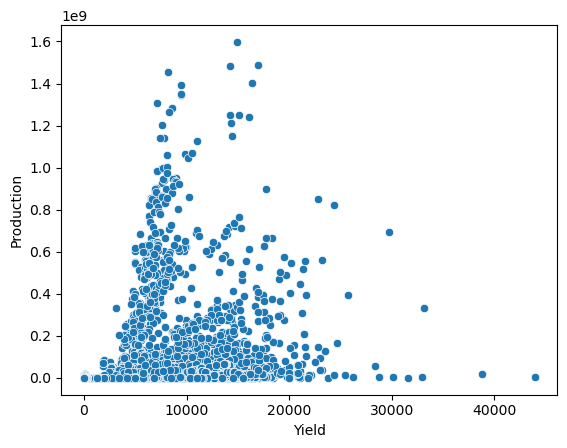

In [31]:
sns.scatterplot(x='Yield', y='Production', data=df)

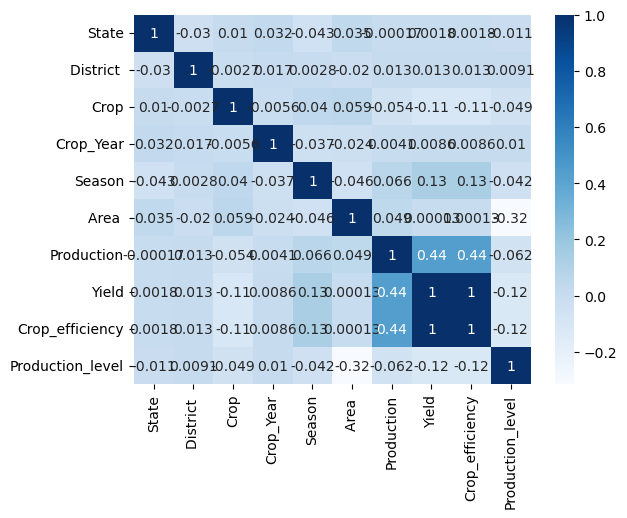

In [18]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

In [19]:
X=df.drop('Crop_efficiency',axis=1)
y=df['Crop_efficiency']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [23]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

In [25]:
lr_metrics = evaluate(lr, X_test, y_test)
dt_metrics = evaluate(dt, X_test, y_test)
rf_metrics = evaluate(rf, X_test, y_test)

In [26]:
print("Linear Regression:", lr_metrics)

Linear Regression: (0.00372879421523342, 0.1541381144377303, 0.9999999722573226)


In [27]:
print("Decision Tree:", dt_metrics)

Decision Tree: (0.19659418015980865, 21.11216998761527, 0.999479531996876)


In [28]:
print("Random Forest:", rf_metrics)

Random Forest: (0.10394697054805382, 8.271896553551459, 0.999920101527478)


In [32]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

            Feature    Importance
7             Yield  9.998171e-01
6        Production  7.021419e-05
3         Crop_Year  5.494316e-05
5             Area   4.076032e-05
1         District   1.212570e-05
0             State  4.861687e-06
2              Crop  1.771018e-08
4            Season  1.346486e-08
8  Production_level  6.006699e-09


In [35]:
# Predict using trained model
y_pred = rf.predict(X_test)

# Create comparison table (first 10 values)
final_results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(final_results)

      Actual  Predicted
0   2.352944   2.350247
1  19.904769  19.897357
2   0.875000   0.875000
3   1.195122   1.200539
4   1.000000   1.000000
5   0.560000   0.559733
6   3.951220   3.950004
7  38.777778  38.777096
8   0.321044   0.319473
9   0.917772   0.919482


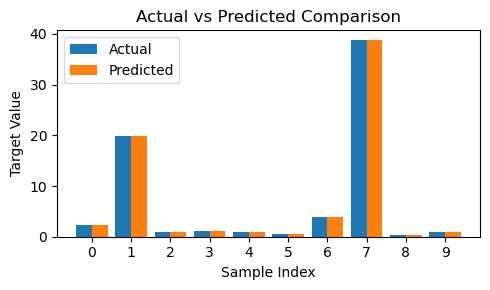

In [38]:
n = 10
actual = y_test.values[:n]
predicted = y_pred[:n]

x = np.arange(n)

plt.figure(figsize=(5,3))

# Bars
plt.bar(x - 0.2, actual, width=0.4, label="Actual")
plt.bar(x + 0.2, predicted, width=0.4, label="Predicted")

# Labels
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("Actual vs Predicted Comparison")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()